# Module 15: Model Training at Scale

**Snowpark ML Fundamentals — Week 4 | Lunch & Learn**

---

## Learning Objectives
1. Understand how Snowpark ML distributes work: **SQL pushdown** for preprocessing, **stored procedure sandbox** for training, and **distributed CV fits** via `n_jobs=-1`
2. Apply **stratified sampling** and **`cache_result()`** to maximize throughput on a Size-S warehouse
3. Master the **coarse-to-fine** hyperparameter tuning strategy with credit estimation
4. Build an end-to-end optimized pipeline from sampling through model registry

## Key Concept
> **Training where the data lives IS scaling.** Snowpark ML eliminates data movement — your
> data never leaves Snowflake. Preprocessing translates to distributed SQL across all warehouse
> nodes. Since v1.1.0, GridSearchCV/RandomizedSearchCV distribute CV fits across multi-node
> warehouses with `n_jobs=-1`. On a Size-S warehouse, you maximize this architecture by caching
> preprocessed data, sampling strategically for tuning, and training the final model on full data.
> This is not "using less data" — it is the same pattern Google, Meta, and Netflix use:
> **explore cheaply, exploit fully.**

---

In [1]:
%load_ext autoreload
%autoreload 2

## 15.1 Setup

Create session, generate a **20K-row** churn dataset, preprocess, and split.
We use a larger dataset than earlier modules to make sampling meaningful in Section 15.3.

In [2]:
import sys
sys.path.insert(0, '../src')

import logging
import math
import time
import warnings

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)
logging.getLogger("snowflake.snowpark").setLevel(logging.ERROR)
logging.getLogger("snowflake.ml").setLevel(logging.ERROR)

sns.set_theme(style="whitegrid", palette="colorblind", font_scale=1.1)

from snowpark_fundamentals.session import create_session
from snowpark_fundamentals.data.sample_data import create_customer_churn_dataset
from snowpark_fundamentals.data.loader import split_data, sample_stratified
from snowpark_fundamentals.preprocessing.transformers import build_preprocessing_pipeline
from snowpark_fundamentals.modeling.trainer import train_model, predict, MODEL_REGISTRY
from snowpark_fundamentals.modeling.evaluation import evaluate_binary_classifier, get_confusion_matrix
from snowpark_fundamentals.modeling.tuning import (
    grid_search_cv,
    randomized_search_cv,
    get_search_results,
    get_best_model_params,
)
from snowflake.snowpark import functions as F

session = create_session(env_path='../.env')

NUMERIC_COLS = ['AGE', 'TENURE_MONTHS', 'MONTHLY_CHARGES', 'TOTAL_CHARGES',
                'SUPPORT_TICKETS', 'USAGE_HOURS_PER_WEEK', 'NUM_DEPENDENTS']
CATEGORICAL_COLS = ['PLAN_TYPE', 'CONTRACT_TYPE', 'PAYMENT_METHOD']
LABEL_COL = 'CHURNED'
FEATURE_COLS = [f"{c}_SCALED" for c in NUMERIC_COLS] + [f"{c}_ENCODED" for c in CATEGORICAL_COLS]

# Generate a 20K-row dataset — large enough to make sampling meaningful
df = create_customer_churn_dataset(session, n_rows=20000)
df_processed, _ = build_preprocessing_pipeline(df, NUMERIC_COLS, CATEGORICAL_COLS)
train_df, test_df = split_data(df_processed)
print(f"Train: {train_df.count()} rows, Test: {test_df.count()} rows")

# Class distribution — important for metric choice later
churn_counts = df.group_by(LABEL_COL).count().to_pandas()
print(f"\nClass distribution:\n{churn_counts.to_string(index=False)}")
churn_rate = churn_counts[churn_counts[LABEL_COL] == 1]['COUNT'].values[0] / churn_counts['COUNT'].sum()
print(f"Churn rate: {churn_rate:.1%} — this is imbalanced data")

Train: 15960 rows, Test: 4040 rows

Class distribution:
 CHURNED  COUNT
       0  15708
       1   4292
Churn rate: 21.5% — this is imbalanced data


[Pricing Guide](https://www.snowflake.com/pricing/pricing-guide/)

In [3]:
# Warehouse info and credit estimation for Size-S
current_wh = session.get_current_warehouse()
print(f"Current warehouse: {current_wh}")

# Size-S standard warehouse = 2 credits/hour
CREDITS_PER_HOUR = 2
print(f"Credit rate: {CREDITS_PER_HOUR} credits/hr (Size-S Standard)")


def estimate_credits(seconds: float) -> float:
    """Estimate warehouse credits consumed for a given wall-clock duration."""
    return CREDITS_PER_HOUR * seconds / 3600


print(f"\nExample: a 60-second job costs {estimate_credits(60):.4f} credits")

Current warehouse: "TASK_WH"
Credit rate: 2 credits/hr (Size-S Standard)

Example: a 60-second job costs 0.0333 credits


## 15.2 How Snowpark ML Actually Runs Your Code

Understanding the **execution model** is the key to optimizing on any warehouse — not just a small one.

### Why Server-Side Execution IS Scaling

Snowflake's own architecture docs state: *"Snowpark pushes down all data transformation and heavy lifting
to the Snowflake data cloud, enabling you to efficiently work with data of any size."* The alternative —
extracting data to a laptop for local training — is the thing that does **not** scale. Training where
the data lives eliminates the ETL bottleneck entirely.

### Three Execution Paths

```
DataFrame
    │
    ▼
1. PREPROCESSING (StandardScaler, OrdinalEncoder)
    │  Translates to SQL → runs DISTRIBUTED on the warehouse's SQL engine
    │  Uses ALL warehouse nodes. Scales with warehouse size.
    │  Ref: "distribute the processing across warehouse compute resources"
    ▼
2. CACHING — cache_result()
    │  Creates a temp table. Avoids recomputing the preprocessing DAG.
    │  Officially recommended: "use cache_result whenever a DataFrame
    │  that is expensive to compute sees high reuse."
    ▼
3. MODEL TRAINING (XGBClassifier.fit(), RandomForest.fit())
    │  Creates a temporary stored procedure.
    │  Data pulled into Python sandbox on a warehouse node.
    │  On Size-S: ~2 GB memory, limited CPU.
    ▼
4. HYPERPARAMETER SEARCH (GridSearchCV, RandomizedSearchCV)
       Since Snowflake ML v1.1.0: "execution is now distributed
       on multi-node warehouses." n_jobs=-1 uses all processors.
```

| Operation | Execution | Size-S Impact |
|-----------|-----------|---------------|
| Preprocessing (scaler, encoder) | Distributed SQL (all nodes) | Fast, scales well |
| `df.sample()`, `df.filter()` | Distributed SQL | Fast, scales well |
| `cache_result()` | Creates temp table | Avoids recomputation |
| Model training (single `fit`) | Python sandbox (1 node) | Memory-limited (~2 GB) |
| GridSearchCV / RandomizedSearchCV | Distributed CV fits (`n_jobs=-1`) | Parallelized across cores |

> **Key insight:** Multi-cluster warehouses help *concurrency* (many users), not single-training speed.
> But `n_jobs=-1` in GridSearchCV/RandomizedSearchCV **does** parallelize CV fits across available
> processors, even on a Size-S. The optimization strategy is: reduce what each fit processes
> (sampling), avoid redundant work (caching), and let the warehouse parallelize the rest.

> Ref: [Snowpark ML Modeling](https://docs.snowflake.com/en/developer-guide/snowflake-ml/modeling) | [GridSearchCV API](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/latest/api/modeling/snowflake.ml.modeling.model_selection.GridSearchCV)

In [4]:
# Demonstrate: preprocessing (SQL) is fast, training (Python sandbox) is slower
# This builds intuition for WHERE to optimize

# Time preprocessing on the full 20K dataset
t0 = time.time()
df_reproc, _ = build_preprocessing_pipeline(df, NUMERIC_COLS, CATEGORICAL_COLS)
_ = df_reproc.count()  # Force evaluation
preproc_time = time.time() - t0

# Time a single model training on the preprocessed data
t0 = time.time()
model_baseline = train_model(
    train_df, FEATURE_COLS, LABEL_COL,
    model_type='xgboost',
    model_params={'n_estimators': 50, 'max_depth': 4},
)
train_time = time.time() - t0

print(f"Preprocessing (SQL pushdown):   {preproc_time:.1f}s  |  {estimate_credits(preproc_time):.4f} credits")
print(f"Model training (Python sandbox): {train_time:.1f}s  |  {estimate_credits(train_time):.4f} credits")
print(f"\nTraining is {train_time/max(preproc_time, 0.01):.1f}x slower — that's the bottleneck to optimize.")

Preprocessing (SQL pushdown):   10.8s  |  0.0060 credits
Model training (Python sandbox): 20.2s  |  0.0112 credits

Training is 1.9x slower — that's the bottleneck to optimize.


## 15.3 Smart Data Strategies: Sampling & Caching

### "Isn't sampling just avoiding the problem?"

No. Sampling for hyperparameter search is a **standard ML practice**, not a workaround:
- Snowflake's own ML estimators internally use stratified sampling for early stopping validation
- The final model is ALWAYS trained on **full data** — sampling only accelerates the search phase
- This is how production ML works at every scale: Google trains BERT on subsets for architecture search, then trains the final model on the full corpus

### Sampling
- **Random**: `df.sample(frac=0.5)` — fast, server-side, good for prototyping
- **Stratified**: `sample_stratified(df, label_col, frac=0.5)` — preserves class balance (critical for imbalanced data like churn)
- **SQL TABLESAMPLE**: block-level sampling, fastest for very large tables

### Caching
- **`df.cache_result()`** — materializes the DataFrame as a temp table. Without caching, every `fit()` call inside GridSearchCV re-executes the **entire** preprocessing DAG from scratch. With caching, preprocessing runs **once**.
- Snowflake docs: *"It is recommended to use cache_result whenever a DataFrame that is expensive to compute sees high reuse."*

> **Production pattern:** Sample for hyperparameter search (fast iterations) → train the final model on **full data** with the best parameters found.

In [5]:
# --- Sampling Methods ---

# 1. Random sampling: 50% of preprocessed data
df_random_sample = train_df.sample(frac=0.5)
print(f"Original train size:  {train_df.count()} rows")
print(f"Random 50% sample:    {df_random_sample.count()} rows")

# 2. Stratified sampling: preserves class distribution
df_stratified = sample_stratified(train_df, LABEL_COL, frac=0.5)
stratified_counts = df_stratified.group_by(LABEL_COL).count().to_pandas()
print(f"\nStratified 50% sample: {df_stratified.count()} rows")
print(f"Class distribution preserved:")
print(stratified_counts.to_string(index=False))

# Use stratified sample for all tuning in this notebook
df_tune = df_stratified
print(f"\n>>> Using stratified sample ({df_tune.count()} rows) for hyperparameter tuning")

Original train size:  15960 rows
Random 50% sample:    8033 rows

Stratified 50% sample: 7942 rows
Class distribution preserved:
 CHURNED  COUNT
       0   6170
       1   1694

>>> Using stratified sample (7957 rows) for hyperparameter tuning


In [6]:
# --- Caching: avoid re-executing the preprocessing DAG ---

# cache_result() materializes as a temp table — preprocessing runs ONCE
df_tune_cached = df_tune.cache_result()
tune_train, tune_test = split_data(df_tune_cached)
print(f"Cached tuning set: {df_tune_cached.count()} rows (materialized as temp table)")
print(f"Tune train: {tune_train.count()} rows, Tune test: {tune_test.count()} rows")

# Also cache the full training data for final model training later
df_train_cached = train_df.cache_result()
print(f"Cached full train: {df_train_cached.count()} rows")

# Demonstrate the speed benefit: time a training run on cached data
t0 = time.time()
_ = train_model(tune_train, FEATURE_COLS, LABEL_COL, model_type='xgboost',
                model_params={'n_estimators': 50, 'max_depth': 4})
cached_train_time = time.time() - t0
print(f"\nTraining on cached sample: {cached_train_time:.1f}s  |  {estimate_credits(cached_train_time):.4f} credits")
print(f"(vs. {train_time:.1f}s on full uncached data — {train_time/max(cached_train_time, 0.01):.1f}x faster)")

Cached tuning set: 8029 rows (materialized as temp table)
Tune train: 6392 rows, Tune test: 1637 rows
Cached full train: 15960 rows

Training on cached sample: 14.9s  |  0.0083 credits
(vs. 20.2s on full uncached data — 1.4x faster)


## 15.4 Scoring Metrics for Imbalanced Data

Our churn dataset is ~78% non-churn / ~22% churn. A model that predicts "no churn" for every customer achieves **78% accuracy** — and catches **zero** actual churners.

| Metric | What it measures | When to use |
|--------|-----------------|-------------|
| `accuracy` | Overall correct predictions | Balanced classes |
| `f1` | Harmonic mean of precision & recall | Imbalanced classes (default choice) |
| `roc_auc` | Ranking quality across thresholds | When you need probability ordering |

**Rule of thumb:** If the minority class is <30% of the data, use `f1` or `roc_auc` as your CV scoring metric, not `accuracy`.

Let's run the same small grid with both metrics and compare. Note we use `cv=3` (not 5) to reduce total fits — budget-conscious on Size-S.

In [7]:
# Small grid: 2 x 2 x 2 = 8 combinations, cv=3 → 24 fits (budget-conscious)
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1],
}

n_combos = 2 * 2 * 2
cv_folds = 3
print(f"Grid: {n_combos} combinations x {cv_folds} folds = {n_combos * cv_folds} fits")

# Run with scoring='accuracy' — n_jobs=-1 distributes CV fits across warehouse processors
t0 = time.time()
grid_acc = grid_search_cv(
    tune_train, FEATURE_COLS, LABEL_COL,
    model_type='xgboost', param_grid=param_grid,
    cv=cv_folds, scoring='accuracy', n_jobs=-1,
)
grid_acc_time = time.time() - t0
best_acc = get_best_model_params(grid_acc)

# Run with scoring='f1'
t0 = time.time()
grid_f1 = grid_search_cv(
    tune_train, FEATURE_COLS, LABEL_COL,
    model_type='xgboost', param_grid=param_grid,
    cv=cv_folds, scoring='f1', n_jobs=-1,
)
grid_f1_time = time.time() - t0
best_f1 = get_best_model_params(grid_f1)

# Compare
print(f"\nscoring='accuracy' → best params: {best_acc['best_params']}")
print(f"  Best CV accuracy: {best_acc['best_score']:.4f}  |  {grid_acc_time:.1f}s  |  {estimate_credits(grid_acc_time):.4f} credits")
print(f"\nscoring='f1'       → best params: {best_f1['best_params']}")
print(f"  Best CV F1:       {best_f1['best_score']:.4f}  |  {grid_f1_time:.1f}s  |  {estimate_credits(grid_f1_time):.4f} credits")

if best_acc['best_params'] != best_f1['best_params']:
    print("\nThe best hyperparameters CHANGED — the metric you optimize shapes the model you get.")
else:
    print("\nSame params won under both metrics (uncommon with imbalanced data).")

Grid: 8 combinations x 3 folds = 24 fits

scoring='accuracy' → best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 100}
  Best CV accuracy: 0.8633  |  42.7s  |  0.0237 credits

scoring='f1'       → best params: {'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 200}
  Best CV F1:       0.5148  |  43.2s  |  0.0240 credits

The best hyperparameters CHANGED — the metric you optimize shapes the model you get.


## 15.5 Coarse-to-Fine Tuning: The Budget-Conscious Pattern

The most effective hyperparameter tuning strategy for constrained environments is **two stages**:

1. **Coarse search** (RandomizedSearchCV, n_iter=15): Explore a wide space cheaply. Identify the *region* that works.
2. **Fine search** (GridSearchCV around the winner): Build a tight grid centered on the best parameters from stage 1. Exhaustively search the neighborhood.

This is strictly better than running either search alone:
- **Cheaper** than a full grid over the wide space
- **More thorough** than random search alone in the winning region

```
Wide Random Search (15 samples from 3,750 combos)
       │  n_jobs=-1 → CV fits distributed across warehouse processors
       ▼
Best region identified
       │
       ▼
Focused Grid Search (neighbors of best params)
       │  n_jobs=-1 → same distributed parallelism
       ▼
Final best hyperparameters
```

### Credit Budget Calculator

Before launching any search, estimate the cost:
- **Expected fits** = `n_combinations × cv_folds`
- **Estimated time** ≈ `fits × avg_time_per_fit` (parallelized by n_jobs)
- **Estimated credits** = `credits_per_hour × total_time / 3600`

> Ref: [RandomizedSearchCV API](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/latest/api/modeling/snowflake.ml.modeling.model_selection.RandomizedSearchCV)

In [8]:
# Stage 1: Coarse search — wide parameter space, limited budget
param_distributions = {
    'n_estimators': [50, 100, 150, 200, 300],
    'max_depth': [3, 4, 5, 6, 8, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
}

total_grid = math.prod(len(v) for v in param_distributions.values())
n_iter = 15
print(f"Full grid would be {total_grid} combinations x {cv_folds} folds = {total_grid * cv_folds} fits")
print(f"RandomizedSearchCV samples {n_iter} combinations x {cv_folds} folds = {n_iter * cv_folds} fits")
print(f"Reduction: {n_iter / total_grid:.1%} of the full grid\n")

t0 = time.time()
random_search = randomized_search_cv(
    tune_train,
    feature_cols=FEATURE_COLS,
    label_col=LABEL_COL,
    model_type='xgboost',
    param_distributions=param_distributions,
    n_iter=n_iter,
    cv=cv_folds,
    scoring='f1',
    n_jobs=-1,  # Distribute CV fits across all warehouse processors
    random_state=42,
)
random_time = time.time() - t0

random_best = get_best_model_params(random_search)
print(f"Best params: {random_best['best_params']}")
print(f"Best CV F1: {random_best['best_score']:.4f}")
print(f"Candidates evaluated: {random_best['n_candidates_evaluated']}")
print(f"Wall time: {random_time:.1f}s  |  Credits: {estimate_credits(random_time):.4f}")

Full grid would be 3750 combinations x 3 folds = 11250 fits
RandomizedSearchCV samples 15 combinations x 3 folds = 45 fits
Reduction: 0.4% of the full grid

Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV F1: 0.5114
Candidates evaluated: 15
Wall time: 41.9s  |  Credits: 0.0233


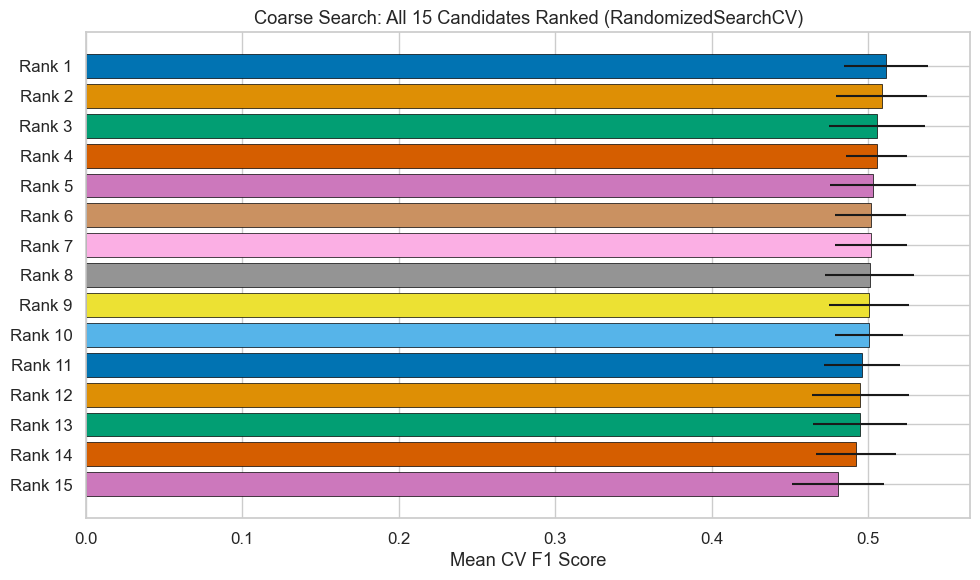

Top 3 configurations:
  Rank 1: F1=0.5114 (+/- 0.0269) — {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
  Rank 2: F1=0.5084 (+/- 0.0292) — {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 10, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
  Rank 3: F1=0.5055 (+/- 0.0308) — {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [9]:
# Visualize all 15 candidates with error bars
random_results = get_search_results(random_search)
random_results_df = pd.DataFrame(random_results)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('colorblind', len(random_results_df))
ax.barh(
    range(len(random_results_df)),
    random_results_df['mean_test_score'],
    xerr=random_results_df['std_test_score'],
    color=colors,
    edgecolor='black', linewidth=0.5,
)
ax.set_yticks(range(len(random_results_df)))
ax.set_yticklabels([f"Rank {r}" for r in random_results_df['rank_test_score']])
ax.set_xlabel('Mean CV F1 Score')
ax.set_title('Coarse Search: All 15 Candidates Ranked (RandomizedSearchCV)')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 3 configurations:")
for _, row in random_results_df.head(3).iterrows():
    print(f"  Rank {row['rank_test_score']}: F1={row['mean_test_score']:.4f} "
          f"(+/- {row['std_test_score']:.4f}) — {row['params']}")

In [10]:
# Stage 2: Build a focused grid around the randomized search winner
best = random_best['best_params']


def neighborhood(values_list, best_val):
    """Return the best value and its immediate neighbors from the original list."""
    sorted_vals = sorted(values_list)
    idx = sorted_vals.index(best_val) if best_val in sorted_vals else 0
    lo = max(0, idx - 1)
    hi = min(len(sorted_vals), idx + 2)
    return sorted_vals[lo:hi]


focused_grid = {
    key: neighborhood(param_distributions[key], best[key])
    for key in param_distributions
}

n_focused = math.prod(len(v) for v in focused_grid.values())
print(f"Focused grid: {n_focused} combinations (vs. {total_grid} full grid)")
print(f"Reduction: {n_focused / total_grid:.1%} of the full grid\n")
for k, v in focused_grid.items():
    print(f"  {k}: {v}  (best was {best[k]})")

Focused grid: 162 combinations (vs. 3750 full grid)
Reduction: 4.3% of the full grid

  n_estimators: [50, 100, 150]  (best was 100)
  max_depth: [4, 5, 6]  (best was 5)
  learning_rate: [0.05, 0.1, 0.2]  (best was 0.1)
  subsample: [0.7, 0.8, 0.9]  (best was 0.8)
  colsample_bytree: [0.9, 1.0]  (best was 1.0)


In [11]:
# Run the focused grid search — n_jobs=-1 for maximum warehouse parallelism
print(f"Focused grid: {n_focused} combinations x {cv_folds} folds = {n_focused * cv_folds} fits")

t0 = time.time()
focused_search = grid_search_cv(
    tune_train, FEATURE_COLS, LABEL_COL,
    model_type='xgboost',
    param_grid=focused_grid,
    cv=cv_folds,
    scoring='f1',
    n_jobs=-1,
)
focused_time = time.time() - t0
focused_best = get_best_model_params(focused_search)

print(f"\nFocused grid best CV F1: {focused_best['best_score']:.4f}")
print(f"Focused grid best params: {focused_best['best_params']}")
print(f"Wall time: {focused_time:.1f}s  |  Credits: {estimate_credits(focused_time):.4f}")

Focused grid: 162 combinations x 3 folds = 486 fits

Focused grid best CV F1: 0.5164
Focused grid best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}
Wall time: 46.9s  |  Credits: 0.0261


               Strategy Candidates Best Score   Metric Wall Time (s) Est. Credits
GridSearchCV (accuracy)          8     0.8633 accuracy          42.7       0.0237
RandomizedSearchCV (f1)         15     0.5114       f1          41.9       0.0233
       Coarse→Fine (f1)     15+162     0.5164       f1          88.8       0.0494


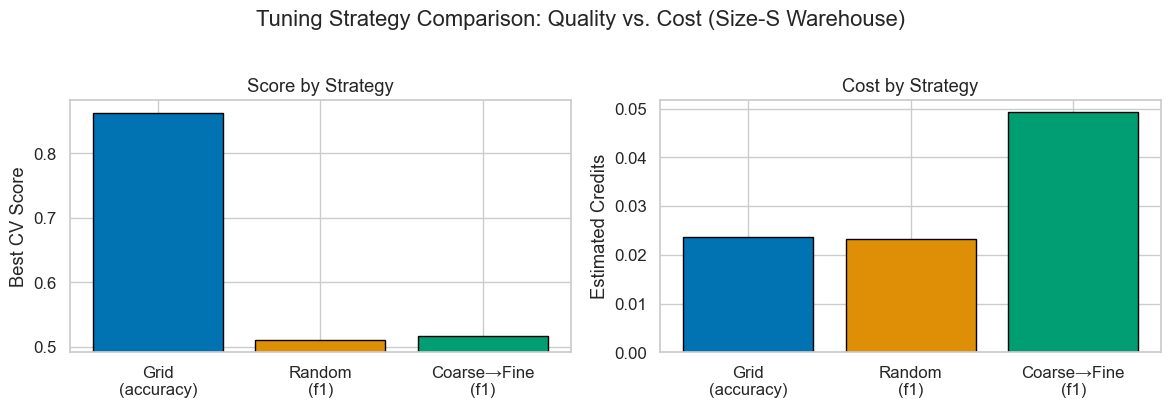

In [12]:
# Three-strategy comparison: score vs cost
total_coarse_fine_time = random_time + focused_time

comparison = pd.DataFrame([
    {
        'Strategy': 'GridSearchCV (accuracy)',
        'Candidates': best_acc['n_candidates_evaluated'],
        'Best Score': f"{best_acc['best_score']:.4f}",
        'Metric': 'accuracy',
        'Wall Time (s)': f"{grid_acc_time:.1f}",
        'Est. Credits': f"{estimate_credits(grid_acc_time):.4f}",
    },
    {
        'Strategy': 'RandomizedSearchCV (f1)',
        'Candidates': random_best['n_candidates_evaluated'],
        'Best Score': f"{random_best['best_score']:.4f}",
        'Metric': 'f1',
        'Wall Time (s)': f"{random_time:.1f}",
        'Est. Credits': f"{estimate_credits(random_time):.4f}",
    },
    {
        'Strategy': 'Coarse→Fine (f1)',
        'Candidates': f"{random_best['n_candidates_evaluated']}+{focused_best['n_candidates_evaluated']}",
        'Best Score': f"{focused_best['best_score']:.4f}",
        'Metric': 'f1',
        'Wall Time (s)': f"{total_coarse_fine_time:.1f}",
        'Est. Credits': f"{estimate_credits(total_coarse_fine_time):.4f}",
    },
])
print(comparison.to_string(index=False))

# Side-by-side bar charts: score vs cost
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
strategies = ['Grid\n(accuracy)', 'Random\n(f1)', 'Coarse→Fine\n(f1)']
scores = [best_acc['best_score'], random_best['best_score'], focused_best['best_score']]
credits = [
    estimate_credits(grid_acc_time),
    estimate_credits(random_time),
    estimate_credits(total_coarse_fine_time),
]

colors = sns.color_palette('colorblind', 3)
ax1.bar(strategies, scores, color=colors, edgecolor='black')
ax1.set_ylabel('Best CV Score')
ax1.set_title('Score by Strategy')
ax1.set_ylim(min(scores) - 0.02, max(scores) + 0.02)

ax2.bar(strategies, credits, color=colors, edgecolor='black')
ax2.set_ylabel('Estimated Credits')
ax2.set_title('Cost by Strategy')

fig.suptitle('Tuning Strategy Comparison: Quality vs. Cost (Size-S Warehouse)', y=1.02)
plt.tight_layout()
plt.show()

## 15.6 Algorithm Efficiency on Small Warehouses

Not all algorithms are equal on a Size-S warehouse. Memory and training time vary significantly:

| Algorithm | Speed | Memory | Best For |
|-----------|-------|--------|----------|
| `LogisticRegression` | Very fast | Minimal | Baseline, linearly separable problems |
| `XGBClassifier` (shallow) | Fast | Low | n_estimators≤100, max_depth≤4 |
| `RandomForestClassifier` | Moderate | Moderate | Ensemble diversity, feature importance |

**Guidance for Size-S:**
- Always start with a **LogisticRegression baseline** — it trains in seconds and sets the bar
- Use **XGBoost with shallow trees** for most problems — good accuracy/speed tradeoff
- Avoid deep trees (max_depth>8) and many estimators (n_estimators>300) during exploration
- Reserve expensive configurations for the final model after tuning identifies the best region

> Ref: [Snowpark ML Modeling Classes](https://docs.snowflake.com/en/developer-guide/snowpark-ml/reference/latest/modeling)

In [13]:
# Benchmark: train all 3 model types on the full 20K preprocessed data
results = []
for model_type in ['logistic_regression', 'xgboost', 'random_forest']:
    params = {}
    if model_type == 'xgboost':
        params = {'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.1}
    elif model_type == 'random_forest':
        params = {'n_estimators': 100, 'max_depth': 6}

    t0 = time.time()
    model = train_model(df_train_cached, FEATURE_COLS, LABEL_COL,
                        model_type=model_type, model_params=params)
    elapsed = time.time() - t0

    preds = predict(model, test_df)
    metrics = evaluate_binary_classifier(preds, LABEL_COL, 'PREDICTION')
    results.append({
        'Algorithm': model_type,
        'Train Time (s)': f"{elapsed:.1f}",
        'Credits': f"{estimate_credits(elapsed):.4f}",
        **{k: f"{v:.4f}" for k, v in metrics.items()},
    })
    print(f"{model_type:25s}  {elapsed:5.1f}s  acc={metrics['accuracy']:.4f}  f1={metrics['f1_score']:.4f}")

results_df = pd.DataFrame(results)
print(f"\n{results_df.to_string(index=False)}")

logistic_regression         13.8s  acc=0.8002  f1=0.1063
xgboost                     15.4s  acc=0.8599  f1=0.5035
random_forest               44.1s  acc=0.8584  f1=0.4938

          Algorithm Train Time (s) Credits accuracy precision recall f1_score
logistic_regression           13.8  0.0077   0.8002    0.9231 0.0564   0.1063
            xgboost           15.4  0.0086   0.8599    0.9931 0.3373   0.5035
      random_forest           44.1  0.0245   0.8584    1.0000 0.3278   0.4938


## 15.7 End-to-End Optimized Pipeline: Sample → Tune → Train Full → Register

Putting it all together. The key insight: **tune on a sample, train the final model on full data.**

```
Full Data (20K) → Preprocess (SQL, fast) → cache_result()
  │
  ├──► Sample 50% for tuning (stratified)
  │         │
  │         ├──► Coarse search (RandomizedSearchCV, n_iter=15, cv=3)
  │         │
  │         ├──► Fine search (GridSearchCV around winner)
  │         │
  │         └──► Best hyperparameters found
  │
  └──► Train FINAL model on FULL cached data with best params
              │
              ├──► Holdout evaluation (test_df)
              │
              └──► Register + log provenance → set 'production' alias
```

> The coarse-to-fine search above already found the best hyperparameters. Now we train a fresh model on **all** training data (not the 50% sample) using those parameters.

Training final model with best params: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.9}
Training time: 16.3s  |  Credits: 0.0091

Final model holdout metrics:
  accuracy: 0.8606
  precision: 0.9932
  recall: 0.3408
  f1_score: 0.5074


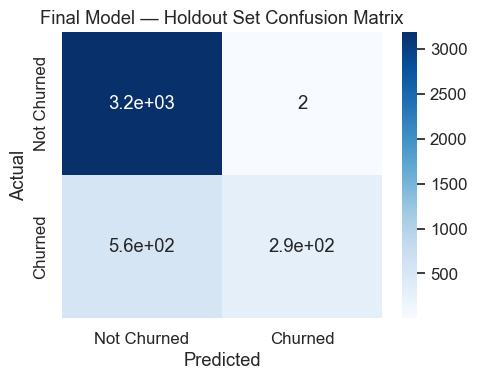

In [14]:
# Train the FINAL model on FULL cached training data with best params from coarse-to-fine
final_params = focused_best['best_params']
print(f"Training final model with best params: {final_params}")

t0 = time.time()
final_model = train_model(
    df_train_cached, FEATURE_COLS, LABEL_COL,
    model_type='xgboost',
    model_params=final_params,
)
final_train_time = time.time() - t0
print(f"Training time: {final_train_time:.1f}s  |  Credits: {estimate_credits(final_train_time):.4f}")

# Evaluate on the full holdout test set
preds_final = predict(final_model, test_df)
metrics_final = evaluate_binary_classifier(preds_final, LABEL_COL, 'PREDICTION')

print(f"\nFinal model holdout metrics:")
for metric, value in metrics_final.items():
    print(f"  {metric}: {value:.4f}")

# Confusion matrix visualization
cm = get_confusion_matrix(preds_final, LABEL_COL, 'PREDICTION')
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, cmap='Blues', ax=ax,
    xticklabels=['Not Churned', 'Churned'],
    yticklabels=['Not Churned', 'Churned'],
)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Final Model — Holdout Set Confusion Matrix')
plt.tight_layout()
plt.show()

In [15]:
from snowpark_fundamentals.registry.model_registry import (
    get_registry, log_model, delete_model, set_model_alias,
    set_model_comment, list_versions, get_model_metrics,
)

current_db = session.get_current_database().replace('"', '')
current_schema = session.get_current_schema().replace('"', '')
registry = get_registry(session, current_db, current_schema)

# Clean up from previous runs
try:
    delete_model(registry, 'CHURN_TUNED')
    print("Deleted existing CHURN_TUNED (re-run cleanup)")
except Exception:
    pass

sample_input = test_df.select(FEATURE_COLS).limit(10)

# Register the final model (trained on full data with tuned params)
mv = log_model(
    registry=registry,
    model=final_model.to_xgboost(),
    model_name='CHURN_TUNED',
    version_name='V1_COARSE_TO_FINE',
    sample_input=sample_input,
    metrics=metrics_final,
)
print("Registered CHURN_TUNED V1_COARSE_TO_FINE")

# Set production alias
set_model_alias(registry, 'CHURN_TUNED', 'V1_COARSE_TO_FINE', 'production')
print("Set 'production' alias")

# Log full provenance: strategy, metric, sample fraction, CV score, credits, warehouse
search_config = (
    f"Coarse-to-Fine | RandomizedSearchCV(n_iter={n_iter}, cv={cv_folds}) → "
    f"GridSearchCV({focused_best['n_candidates_evaluated']} combos, cv={cv_folds}) | "
    f"scoring=f1 | sample_frac=0.5 | best_cv_f1={focused_best['best_score']:.4f} | "
    f"total_credits={estimate_credits(total_coarse_fine_time + final_train_time):.4f} | "
    f"warehouse=Size-S"
)
set_model_comment(registry, 'CHURN_TUNED', search_config, version_name='V1_COARSE_TO_FINE')
print(f"Comment: {search_config}")

# Verify
versions_df = list_versions(registry, 'CHURN_TUNED')
print(f"\nRegistered versions:")
print(versions_df[['name', 'aliases', 'is_default_version']].to_string())

stored_metrics = get_model_metrics(registry, 'CHURN_TUNED', 'V1_COARSE_TO_FINE')
print(f"\nStored metrics:")
for k, v in stored_metrics.items():
    print(f"  {k}: {v}")

Model logged successfully.: 100%|██████████| 6/6 [01:12<00:00, 12.00s/it]                          
Registered CHURN_TUNED V1_COARSE_TO_FINE
Set 'production' alias
Comment: Coarse-to-Fine | RandomizedSearchCV(n_iter=15, cv=3) → GridSearchCV(162 combos, cv=3) | scoring=f1 | sample_frac=0.5 | best_cv_f1=0.5164 | total_credits=0.0584 | warehouse=Size-S

Registered versions:
                name                                  aliases is_default_version
0  V1_COARSE_TO_FINE  ["PRODUCTION","DEFAULT","FIRST","LAST"]               true

Stored metrics:
  accuracy: 0.860644
  precision: 0.9931506849315068
  recall: 0.3407755581668625
  f1_score: 0.5074365704286964


## 15.8 When You Need More: Scaling Beyond Size-S

Everything above works within a Size-S standard warehouse. When you outgrow it, Snowflake offers several paths — documented here for reference.

### A. Snowpark-Optimized Warehouses

Provide **16x more memory per node** than standard warehouses. Designed for ML training and large DataFrame operations.

| Size | Standard Memory | Snowpark-Optimized Memory | Credits/hr |
|------|----------------|---------------------------|------------|
| XS   | ~1 GB          | ~16 GB                    | 1.5        |
| S    | ~2 GB          | ~32 GB                    | 3          |
| M    | ~16 GB         | ~256 GB (default)         | 12         |
| L    | ~64 GB         | ~1 TB                     | 24         |

```sql
-- Create a Snowpark-Optimized warehouse (requires CREATE WAREHOUSE privilege)
CREATE WAREHOUSE IF NOT EXISTS ML_TRAINING_WH
    WAREHOUSE_TYPE = 'SNOWPARK-OPTIMIZED'
    WAREHOUSE_SIZE = 'MEDIUM'
    AUTO_SUSPEND = 300
    AUTO_RESUME = TRUE;

-- Use it for training
USE WAREHOUSE ML_TRAINING_WH;
```

> Ref: [Snowpark-Optimized Warehouses](https://docs.snowflake.com/en/user-guide/warehouses-snowpark-optimized)

### B. Container Runtime for ML (GA April 2025)

GPU access via **Compute Pools** with NVIDIA CUDA-X libraries:
- **cuML**: Drop-in replacement for scikit-learn, up to 50x faster on GPU
- **cuDF**: GPU-accelerated DataFrames, up to 60x faster than pandas
- Distributed training across multiple GPU nodes

### C. ML Jobs

Submit distributed training jobs from any IDE:
- **XGBEstimator / LightGBMEstimator**: Distributed gradient boosting on Compute Pools
- **PyTorchDistributor**: Multi-node distributed PyTorch training
- Backed by a Ray cluster — true multi-node parallelism

> Ref: [ML Jobs Overview](https://docs.snowflake.com/en/developer-guide/snowflake-ml/ml-jobs/overview) | [Distributed ML Jobs](https://docs.snowflake.com/en/developer-guide/snowflake-ml/ml-jobs/distributed-ml-jobs)

### D. Snowpark Connect for Spark

Run PySpark on Snowflake compute without a separate Spark cluster. Useful for data access and transformation, but note: **MLlib is NOT supported** — only data operations.

> Ref: [Snowpark Connect](https://docs.snowflake.com/en/developer-guide/snowpark-connect/snowpark-connect-overview)

### Summary

| Need | Solution | Availability |
|------|----------|-------------|
| More memory for training | Snowpark-Optimized WH (Medium+) | GA |
| GPU acceleration | Container Runtime + Compute Pools | GA April 2025 |
| Distributed multi-node training | ML Jobs on Compute Pools | GA April 2025 |
| Spark data access | Snowpark Connect | Preview |

## 15.9 Production Recommendations

| # | Recommendation | Details |
|---|---|---|
| 1 | **Sample for search, full data for final** | Stratified sample (50%) for tuning, final model on 100% |
| 2 | **Cache preprocessed data** | `df.cache_result()` before any tuning loop |
| 3 | **Use coarse-to-fine tuning** | RandomizedSearchCV(n=15, cv=3) → focused GridSearchCV |
| 4 | **Score with f1 or roc_auc** | Accuracy misleads when minority class <30% |
| 5 | **Estimate credits before launching** | `credits = credits_per_hour × wall_seconds / 3600` |
| 6 | **Start with fast models** | LR baseline → XGBoost shallow → expand if needed |
| 7 | **Log full provenance** | Strategy, metric, sample fraction, CV score, credit cost |
| 8 | **Evaluate on full holdout** | CV score estimates; holdout on full data confirms |

### End-to-End Workflow

```
Full Data
    │
    ▼
Preprocessing (SQL pushdown — fast on any warehouse)
    │
    ▼
cache_result() — avoid recomputation
    │
    ├──► Stratified sample 50% for tuning
    │         │
    │         ├──► Coarse search (RandomizedSearchCV, n_iter=15, cv=3)
    │         │
    │         ├──► Fine search (GridSearchCV around winner)
    │         │
    │         └──► Best hyperparameters
    │
    ▼
Train final model on FULL cached data with best params
    │
    ▼
Holdout evaluation (evaluate_binary_classifier)
    │
    ▼
Register + log provenance (log_model + set_model_comment)
    │
    ▼
Deploy by alias (set_model_alias → 'production')
```

## Key Takeaways

1. **Training where the data lives IS scaling** — Snowpark ML eliminates data movement; preprocessing is distributed SQL; CV fits are parallelized with `n_jobs=-1` since v1.1.0
2. **Preprocessing (SQL pushdown) and training (Python sandbox) have different scaling properties** — optimize for the bottleneck: reduce what the sandbox processes, cache to avoid recomputation
3. **Sampling for search, full data for final** — this is standard ML practice, not a workaround. Snowflake's own estimators use it internally.
4. **Coarse-to-fine tuning** (RandomizedSearchCV → focused GridSearchCV) is the budget-conscious pattern — explore wide, exploit deep
5. **Scoring metric shapes your model**: use `f1` or `roc_auc` for imbalanced data, never `accuracy` alone
6. **Estimate credits before launching, log provenance after** — reproducibility and cost awareness are production requirements
7. **Complete workflow**: preprocess (SQL) → cache → sample → tune (n_jobs=-1) → train-full → evaluate → register → deploy

---

**End of Module 15 — Model Training at Scale**

## Cleanup

In [16]:
# Optional: delete the model registered in this notebook
# delete_model(registry, 'CHURN_TUNED')

session.close()